# Creating token embeddings

1. The data is already almost ready for an LLM
2. But lastly let us embed the tokens in a continuous vector representation using an embedding layer
3. Usually, these embedding layers are part of the LLM itself and are updated (trained) during model training

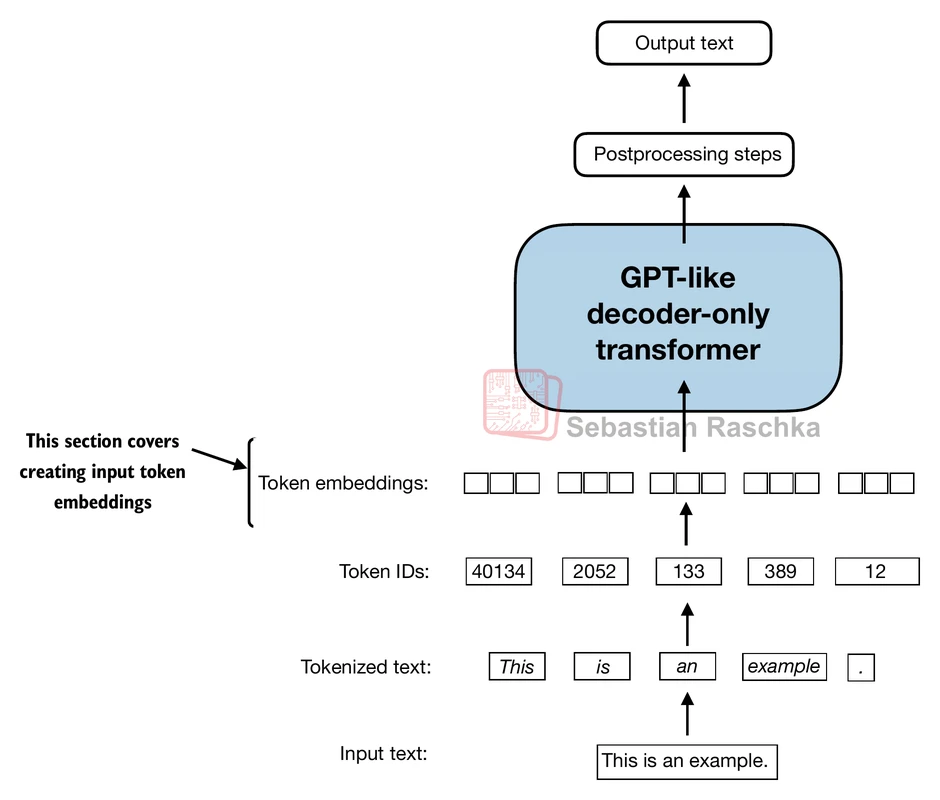

![Screenshot 2026-03-23 at 12.37.42 PM.png](<attachment:Screenshot 2026-03-23 at 12.37.42 PM.png>)
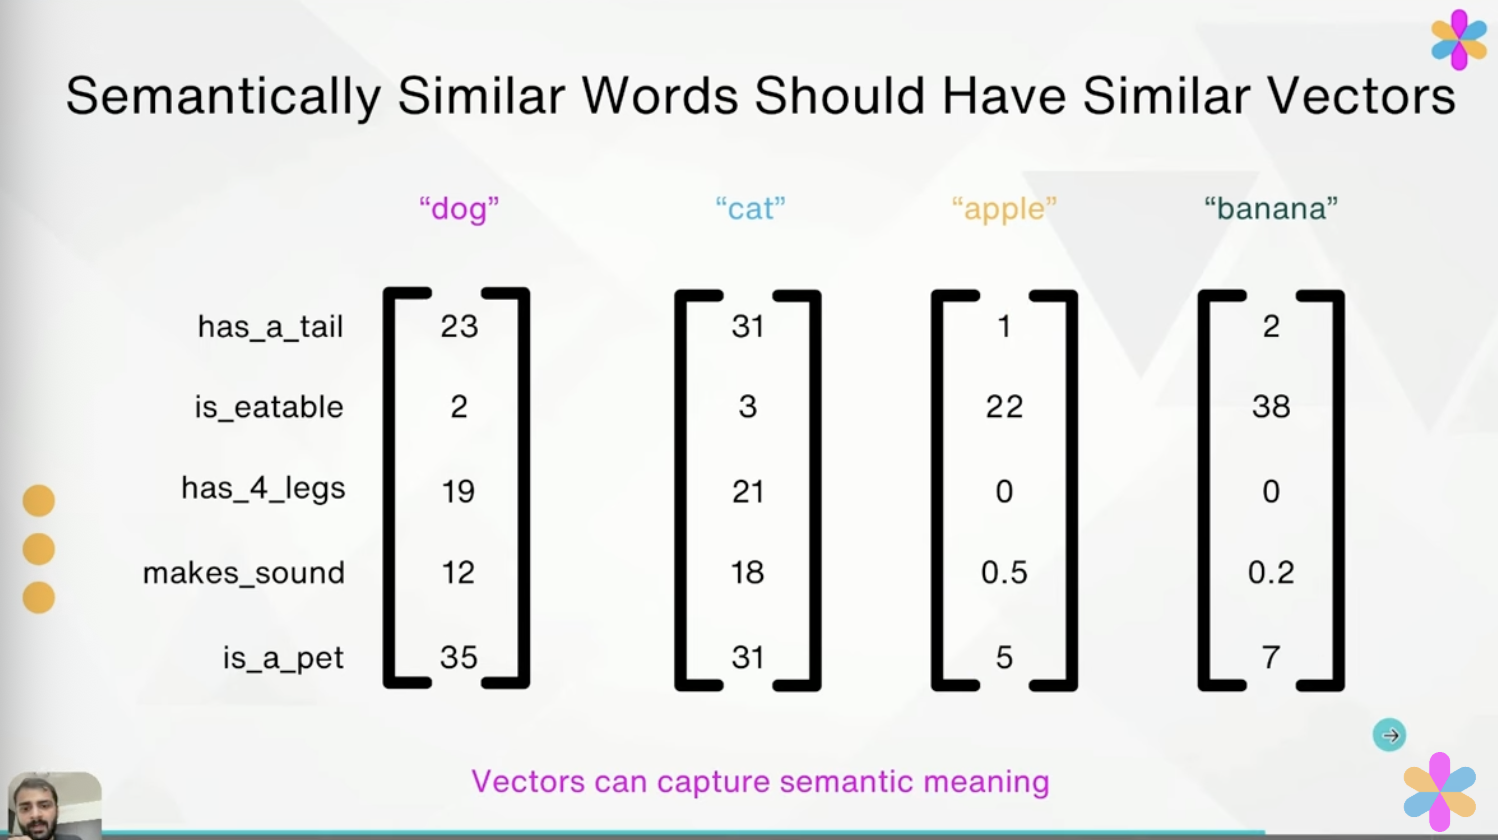

### We can train NeuralNetwork to create vector embedding. 

#### Example

In [1]:
# pip install gensim
import gensim.downloader as api
model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [2]:
word_vectors=model
print(word_vectors['king'])

[ 1.25976562e-01  2.97851562e-02  8.60595703e-03  1.39648438e-01
 -2.56347656e-02 -3.61328125e-02  1.11816406e-01 -1.98242188e-01
  5.12695312e-02  3.63281250e-01 -2.42187500e-01 -3.02734375e-01
 -1.77734375e-01 -2.49023438e-02 -1.67968750e-01 -1.69921875e-01
  3.46679688e-02  5.21850586e-03  4.63867188e-02  1.28906250e-01
  1.36718750e-01  1.12792969e-01  5.95703125e-02  1.36718750e-01
  1.01074219e-01 -1.76757812e-01 -2.51953125e-01  5.98144531e-02
  3.41796875e-01 -3.11279297e-02  1.04492188e-01  6.17675781e-02
  1.24511719e-01  4.00390625e-01 -3.22265625e-01  8.39843750e-02
  3.90625000e-02  5.85937500e-03  7.03125000e-02  1.72851562e-01
  1.38671875e-01 -2.31445312e-01  2.83203125e-01  1.42578125e-01
  3.41796875e-01 -2.39257812e-02 -1.09863281e-01  3.32031250e-02
 -5.46875000e-02  1.53198242e-02 -1.62109375e-01  1.58203125e-01
 -2.59765625e-01  2.01416016e-02 -1.63085938e-01  1.35803223e-03
 -1.44531250e-01 -5.68847656e-02  4.29687500e-02 -2.46582031e-02
  1.85546875e-01  4.47265

## King + Woman - Man = Queen

In [5]:
# king + woman - man
print(word_vectors.most_similar(positive=['king', 'woman'], negative=['man'], topn=1))

[('queen', 0.7118191719055176)]


## how are token embeddings created - 

tokenids are converted to embeddings using Embedding matrix

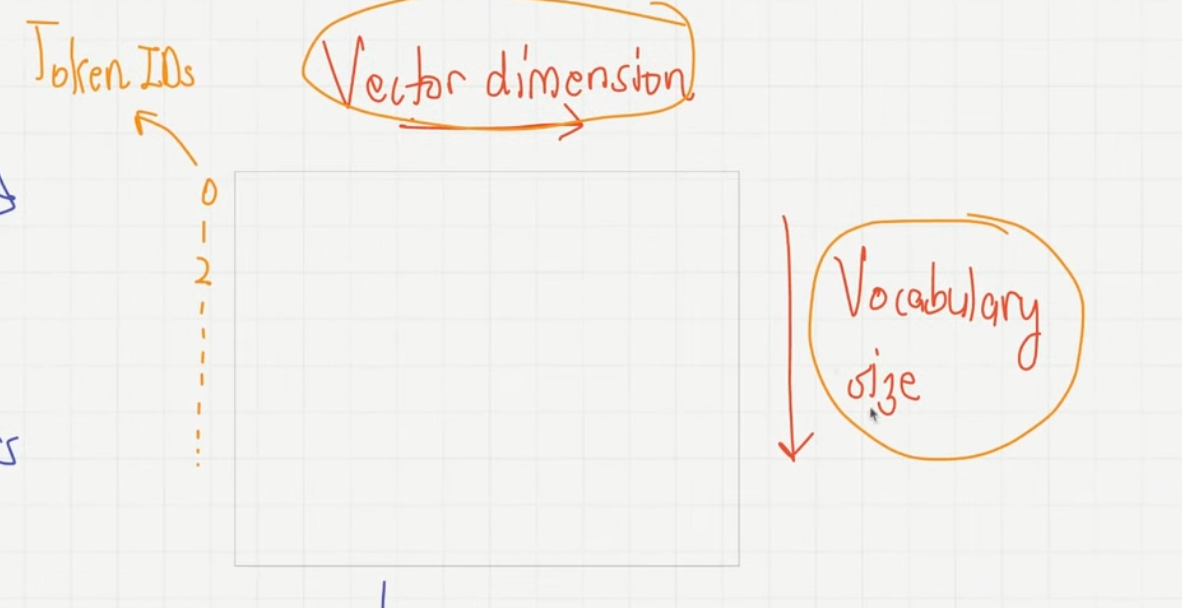

### how embedding matrices are created

1. Initilize embedding weights are random values
2. This initialization serves as the starting point for the LLM learning process
3. The embedding weights are optimized as part of the LLM training process

### Create Token Embeddings

1. 📦 What is the embedding matrix?
Shape: (vocab_size × embedding_dim)
Example: 50,000 × 4096

2. Each row = vector representation of one token.

3. When you have a token ID like: token_id = 1234. The model simply does: embedding = embedding_matrix[1234] 👉 That’s a direct lookup (indexing)

4.   🧮 Why people say it's matrix multiplication
Mathematically, you can represent a token as a one-hot vector:
one_hot = [0, 0, ..., 1, ..., 0]  # length = vocab_size
Then: embedding = one_hot × embedding_matrix. This gives the same result. ⚡ But in real systems… No one actually does the multiplication because: One-hot vectors are huge and sparse, Multiplication would be wasteful

5. 👉 Instead, frameworks like PyTorch use: nn.Embedding → optimized lookup table
⚙️ Internally (PyTorch example)
embedding = torch.nn.Embedding(vocab_size, embedding_dim)
output = embedding(token_ids)

This is implemented as: gather operation (fast memory access), NOT dense matrix multiply

In [6]:
import torch
input_ids = torch.tensor([2,3,5,1])

In [8]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [10]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [11]:
embedding_layer(input_ids) ## Just a lookup but faster than doing it manually

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)

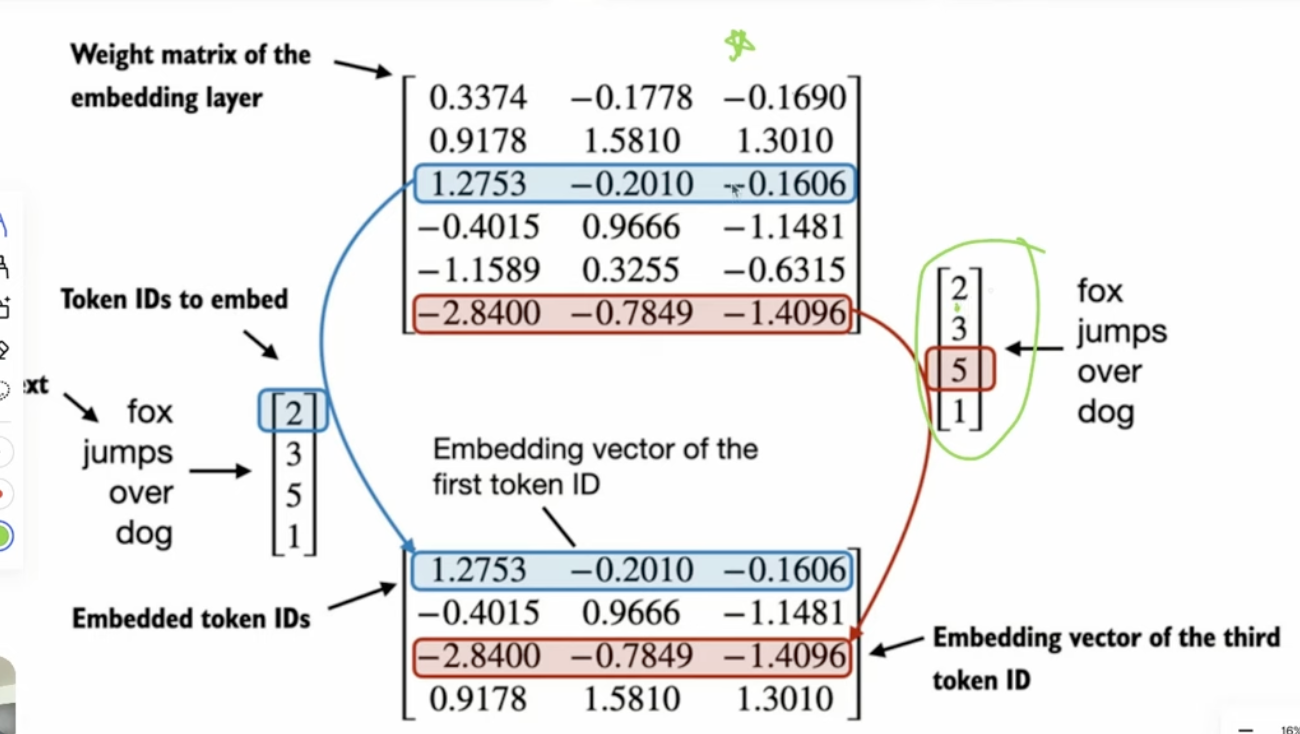

## Difference between nn.Embedding vs nn.Linear

1. Both lead to same output
2. Embedding layer is much more computationally efficient since nn.Linear has many unnecessary multiplications with zero.
